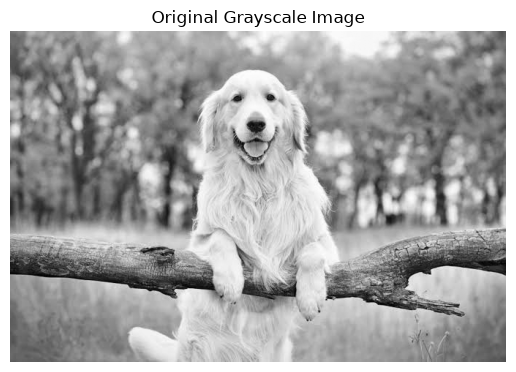

In [48]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("../images/dog_grayscale.png", cv2.IMREAD_GRAYSCALE)

plt.imshow(image, cmap="gray")
plt.title("Original Grayscale Image")
plt.axis("off")
plt.show()

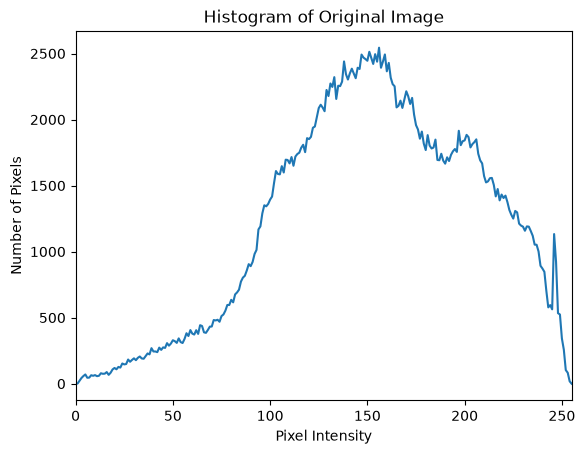

In [49]:
histogram = np.bincount(image.flatten(), minlength=256)

plt.plot(histogram)
plt.title("Histogram of Original Image")
plt.xlabel("Pixel Intensity")
plt.ylabel("Number of Pixels")
plt.xlim([0, 255])
plt.show()

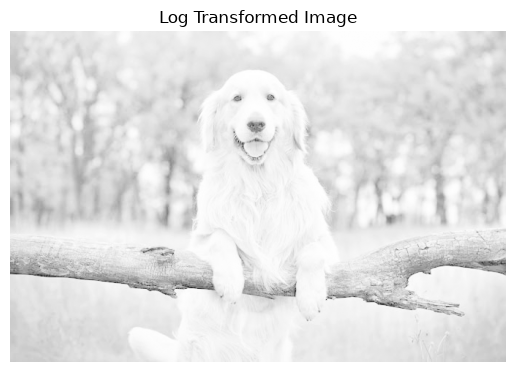

In [50]:
# Scaling constant
c = 255 / np.log(256)

# Log transformation
log_image = c * np.log(1 + image.astype(np.float32))

log_image = np.uint8(log_image)

plt.imshow(log_image, cmap="gray")
plt.title("Log Transformed Image")
plt.axis("off")
plt.show()

In [51]:
cv2.imwrite("../images/dog_log.png", log_image)

True

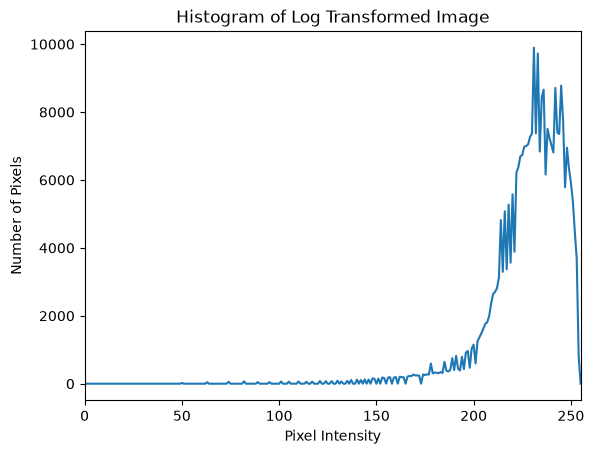

In [52]:
log_histogram = np.bincount(log_image.flatten(),minlength=256)

plt.plot(log_histogram)
plt.title("Histogram of Log Transformed Image")
plt.xlabel("Pixel Intensity")
plt.ylabel("Number of Pixels")
plt.xlim([0, 255])
plt.show()

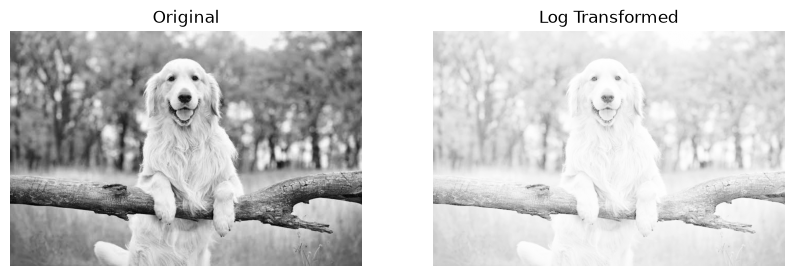

In [53]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(log_image, cmap="gray")
plt.title("Log Transformed")
plt.axis("off")

plt.show()

In [54]:
normalized = image / 255.0

gamma_05 = 0.5
gamma_10 = 1.0
gamma_20 = 2.0

gamma_image_05 = np.uint8(255 * (normalized ** gamma_05))
gamma_image_10 = np.uint8(255 * (normalized ** gamma_10))
gamma_image_20 = np.uint8(255 * (normalized ** gamma_20))

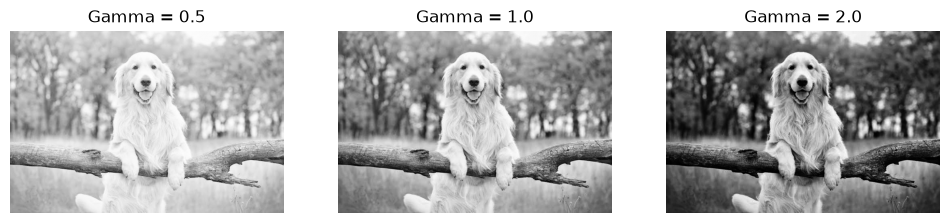

In [55]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(gamma_image_05, cmap="gray")
plt.title("Gamma = 0.5")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gamma_image_10, cmap="gray")
plt.title("Gamma = 1.0")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(gamma_image_20, cmap="gray")
plt.title("Gamma = 2.0")
plt.axis("off")

plt.show()

In [56]:
cv2.imwrite("../images/dog_gamma_05.png", gamma_image_05)
cv2.imwrite("../images/dog_gamma_10.png", gamma_image_10)
cv2.imwrite("../images/dog_gamma_20.png", gamma_image_20)

True

In [62]:
gamma_histogram = np.bincount(gamma_image_05.flatten(), minlength=256)

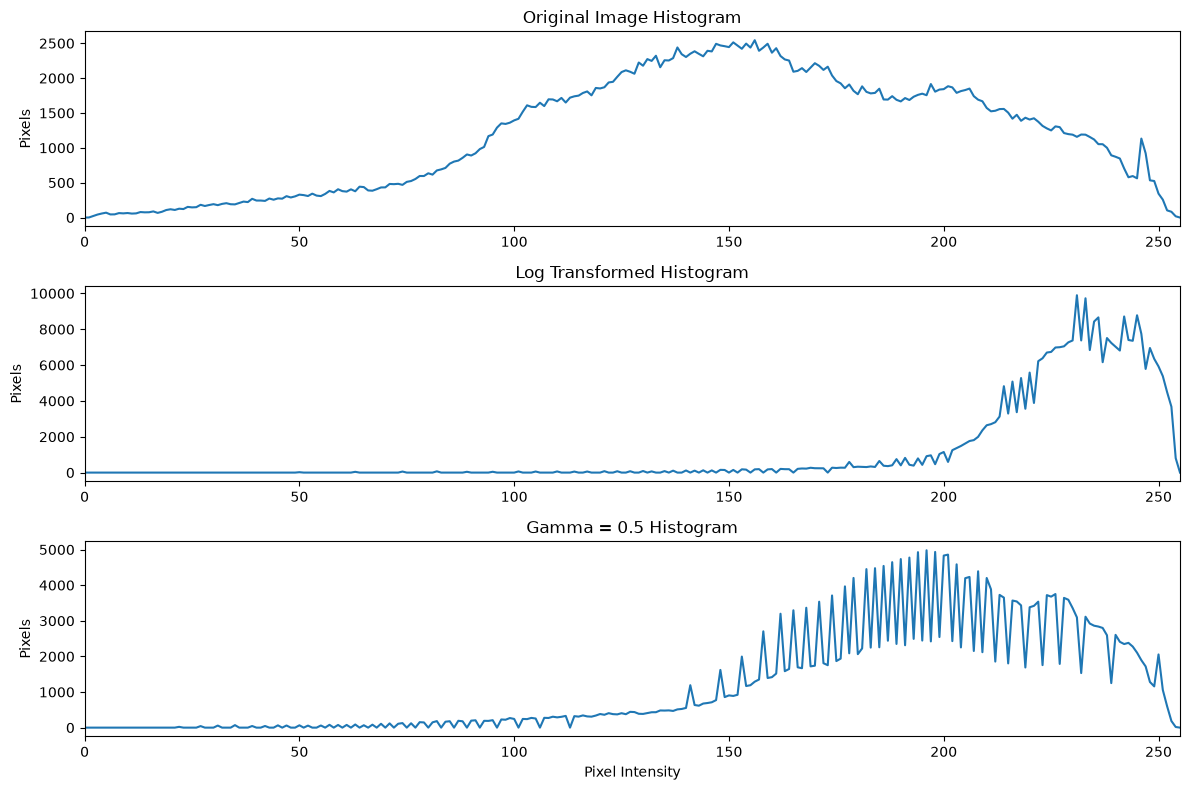

In [63]:
# Histograms

plt.figure(figsize=(12, 8))

plt.subplot(3, 1, 1)
plt.plot(histogram)
plt.title("Original Image Histogram")
plt.xlim([0, 255])
plt.ylabel("Pixels")

plt.subplot(3, 1, 2)
plt.plot(log_histogram)
plt.title("Log Transformed Histogram")
plt.xlim([0, 255])
plt.ylabel("Pixels")

plt.subplot(3, 1, 3)
plt.plot(gamma_histogram)
plt.title("Gamma = 0.5 Histogram")
plt.xlim([0, 255])
plt.xlabel("Pixel Intensity")
plt.ylabel("Pixels")

plt.tight_layout()
plt.show()

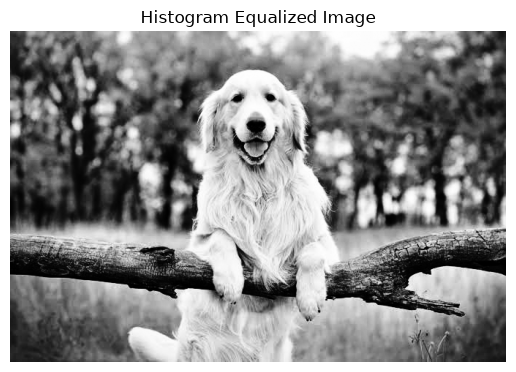

In [58]:
histogram = np.bincount(image.flatten(),minlength=256)

cdf = histogram.cumsum()

# First non-zero value
cdf_min = cdf[cdf > 0][0]

total_pixels = image.size
equalized = ((cdf[image] - cdf_min) / (total_pixels - cdf_min) * 255)

equalized_image = np.uint8(equalized)
plt.imshow(equalized_image, cmap="gray")
plt.title("Histogram Equalized Image")
plt.axis("off")
plt.show()

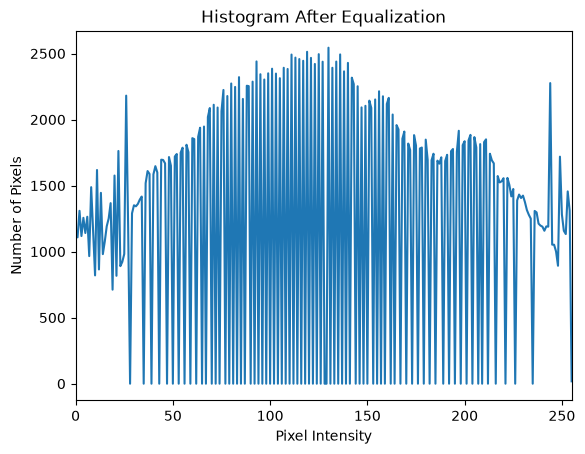

In [ ]:
equalized_histogram = np.bincount(equalized_image.flatten(),minlength=256)

plt.plot(equalized_histogram)
plt.title("Histogram After Equalization")
plt.xlabel("Pixel Intensity")
plt.ylabel("Number of Pixels")
plt.xlim([0, 255])
plt.show()

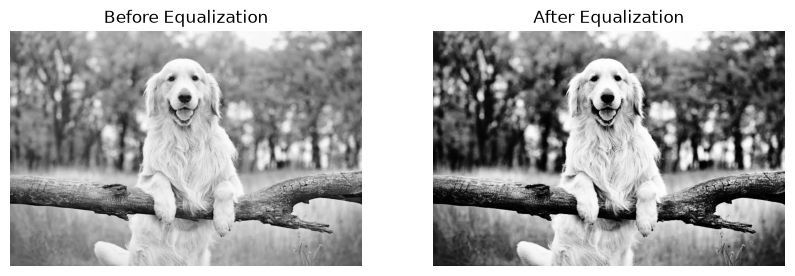

In [60]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Before Equalization")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(equalized_image, cmap="gray")
plt.title("After Equalization")
plt.axis("off")

plt.show()

In [61]:
cv2.imwrite("../images/dog_histogram_equalized.png",equalized_image)

True